<a href="https://colab.research.google.com/github/Avinash603/SAP-Record-to-Report-R2R-/blob/main/SAP_R2R_DataAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 SAP Record-to-Report (R2R) — Data Analytics Engineer
## KIIT SAP PROJECT


---

**Fictitious Company:** TechNova Manufacturing Pvt. Ltd.  
**Scenario:** Month-End Financial Close — March 2026  
**SAP Modules:** FI (Financial Accounting) + SAP Business Data Cloud Analytics

---

## 📋 R2R Process Flow

```
Company & CoA Setup (OX02 / OB13)
         ↓
GL Master Data Creation (FS00)
         ↓
Journal Entry Postings — March 2026 (FB50)
         ↓
Month-End Closing Activities (FBS1 / AFAB / OB52)
         ↓
Financial Statements — P&L + Balance Sheet (F.01)
         ↓
SAP BDC Analytics — KPIs + Dashboards
         R2R Complete
```

## ⚙️ Step 0 — Install Dependencies

In [1]:
!pip install tabulate matplotlib pandas --quiet
print("All dependencies installed successfully!")

All dependencies installed successfully!


## 📦 Step 1 — Imports & Master Data Setup

In [2]:
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── BANNER ──────────────────────────────────────────────────────────────────
def banner(title, width=70):
    print()
    print('═' * width)
    print(f'  {title}')
    print('═' * width)

banner('SAP R2R: Record-to-Report Simulation — TechNova Manufacturing Pvt. Ltd.')
print('  Certification : C_BCBDC — SAP Business Data Cloud')
print('  Company Code  : TN01')
print('  Fiscal Period : March 2026 (Period 12 / FY 2025-26)')
print('  Currency      : INR (Indian Rupee)')
print()

# ── COMPANY MASTER ──────────────────────────────────────────────────────────
COMPANY = {
    'code'       : 'TN01',
    'name'       : 'TechNova Manufacturing Pvt. Ltd.',
    'country'    : 'India',
    'currency'   : 'INR',
    'fiscal_year': 'April–March',
    'coa'        : 'TNCA',
    'city'       : 'Bhubaneswar, Odisha',
}

# ── CHART OF ACCOUNTS (TNCA) ─────────────────────────────────────────────
GL_ACCOUNTS = {
    # Assets
    '100000': {'name': 'Cash in Hand',                 'type': 'Asset',     'group': 'Current Assets'},
    '100100': {'name': 'Bank — HDFC Current Account',  'type': 'Asset',     'group': 'Current Assets'},
    '110000': {'name': 'Accounts Receivable',          'type': 'Asset',     'group': 'Current Assets'},
    '120000': {'name': 'Inventory — Raw Material',     'type': 'Asset',     'group': 'Current Assets'},
    '130000': {'name': 'Prepaid Expenses',             'type': 'Asset',     'group': 'Current Assets'},
    '200000': {'name': 'Plant & Machinery',            'type': 'Asset',     'group': 'Fixed Assets'},
    '210000': {'name': 'Accumulated Depreciation',     'type': 'Asset',     'group': 'Fixed Assets'},
    # Liabilities
    '300000': {'name': 'Accounts Payable',             'type': 'Liability', 'group': 'Current Liabilities'},
    '310000': {'name': 'Short-Term Loans',             'type': 'Liability', 'group': 'Current Liabilities'},
    # Equity
    '400000': {'name': 'Share Capital',                'type': 'Equity',    'group': 'Equity'},
    '410000': {'name': 'Retained Earnings',            'type': 'Equity',    'group': 'Equity'},
    # Revenue
    '500000': {'name': 'Sales Revenue',                'type': 'Revenue',   'group': 'Revenue'},
    '510000': {'name': 'Other Income',                 'type': 'Revenue',   'group': 'Revenue'},
    # Expenses
    '600000': {'name': 'Cost of Goods Sold',           'type': 'Expense',   'group': 'COGS'},
    '610000': {'name': 'Raw Material Consumption',     'type': 'Expense',   'group': 'COGS'},
    '700000': {'name': 'Salaries & Wages',             'type': 'Expense',   'group': 'OpEx'},
    '710000': {'name': 'Rent Expense',                 'type': 'Expense',   'group': 'OpEx'},
    '720000': {'name': 'Electricity & Utilities',      'type': 'Expense',   'group': 'OpEx'},
    '730000': {'name': 'Depreciation Expense',         'type': 'Expense',   'group': 'OpEx'},
    '740000': {'name': 'Office Supplies',              'type': 'Expense',   'group': 'OpEx'},
}

# ── GL BALANCE LEDGER (running balances) ────────────────────────────────
gl_balance = {acc: 0 for acc in GL_ACCOUNTS}

# Seed opening balances
gl_balance['100000'] = 500000   # Cash
gl_balance['400000'] = 500000   # Share Capital (Cr side stored as positive)

posted_documents = []
doc_counter = [1000000000]

print(f' Company Code {COMPANY["code"]} — {COMPANY["name"]} — loaded')
print(f' Chart of Accounts {COMPANY["coa"]} — {len(GL_ACCOUNTS)} GL accounts initialised')


══════════════════════════════════════════════════════════════════════
  SAP R2R: Record-to-Report Simulation — TechNova Manufacturing Pvt. Ltd.
══════════════════════════════════════════════════════════════════════
  Certification : C_BCBDC — SAP Business Data Cloud
  Company Code  : TN01
  Fiscal Period : March 2026 (Period 12 / FY 2025-26)
  Currency      : INR (Indian Rupee)

 Company Code TN01 — TechNova Manufacturing Pvt. Ltd. — loaded
 Chart of Accounts TNCA — 20 GL accounts initialised


## 🗂️ Step 2 — Display GL Master Data (T-Code: FS00)

In [ ]:
banner('SECTION 2: GL MASTER DATA — Chart of Accounts TNCA  [T-Code: FS00]')

rows = [[acc, GL_ACCOUNTS[acc]['name'], GL_ACCOUNTS[acc]['type'], GL_ACCOUNTS[acc]['group']]
        for acc in GL_ACCOUNTS]

print(tabulate(rows,
               headers=['GL Account', 'Description', 'Account Type', 'Account Group'],
               tablefmt='fancy_grid'))
print(f'\n  Total GL Accounts : {len(GL_ACCOUNTS)}')
print(f'  Company Code      : {COMPANY["code"]}')
print(f'  CoA               : {COMPANY["coa"]}')

## 📝 Step 3 — Post Journal Entries (T-Code: FB50)

In [3]:
# ── POSTING ENGINE ───────────────────────────────────────────────────────
def post_journal_entry(date, description, debit_acc, credit_acc, amount, reference=''):
    """Simulates SAP FB50 journal entry posting."""
    doc_counter[0] += 1
    doc_no = str(doc_counter[0])

    # Asset/Expense accounts: Debit increases (+), Credit decreases (-)
    # Liability/Equity/Revenue: Debit decreases (-), Credit increases (+)
    # Simplified: we track net movement; sign convention handled in report
    gl_balance[debit_acc]  += amount
    gl_balance[credit_acc] += amount   # stored as absolute; report logic applies sign

    doc = {
        'doc_no'     : doc_no,
        'date'       : date,
        'description': description,
        'debit_acc'  : debit_acc,
        'credit_acc' : credit_acc,
        'amount'     : amount,
        'reference'  : reference,
        'status'     : 'Posted ',
    }
    posted_documents.append(doc)
    return doc_no


banner('SECTION 3: JOURNAL ENTRY POSTINGS — March 2026  [T-Code: FB50]')
print('  Document Type : SA (G/L Account Document)')
print('  Company Code  : TN01')
print('  Posting Period: 12 / 2026\n')

# ── TRANSACTIONS ─────────────────────────────────────────────────────────
TRANSACTIONS = [
    ('01.03.2026', 'Opening cash — Share Capital injection',       '100000', '400000', 500000,  'OPN-001'),
    ('02.03.2026', 'Cash deposited to HDFC bank',                  '100100', '100000', 400000,  'BANK-001'),
    ('05.03.2026', 'Raw material purchased on credit',             '120000', '300000', 150000,  'PUR-001'),
    ('08.03.2026', 'Sales invoice raised to customer',             '110000', '500000', 300000,  'SALE-001'),
    ('10.03.2026', 'COGS — goods transferred to sales',            '600000', '120000', 80000,   'COGS-001'),
    ('15.03.2026', 'March salary payment (partial)',               '700000', '100100', 75000,   'SAL-001'),
    ('18.03.2026', 'March office rent payment',                    '710000', '100100', 25000,   'RENT-001'),
    ('20.03.2026', 'Electricity bill — accrued payable',           '720000', '300000', 12000,   'ELEC-001'),
    ('22.03.2026', 'Customer payment received — AR clearing',      '100100', '110000', 250000,  'REC-001'),
    ('28.03.2026', 'Vendor payment — AP clearing',                 '300000', '100100', 100000,  'PAY-001'),
    ('31.03.2026', 'Month-end: Depreciation on Plant & Machinery', '730000', '210000', 5000,    'DEP-001'),
    ('31.03.2026', 'Month-end: Office supplies purchased',         '740000', '100100', 3500,    'SUP-001'),
    ('31.03.2026', 'Month-end: Salary accrual (balance)',          '700000', '300000', 10000,   'ACR-001'),
]

results = []
for i, (date, desc, dr, cr, amt, ref) in enumerate(TRANSACTIONS, 1):
    doc_no = post_journal_entry(date, desc, dr, cr, amt, ref)
    results.append([
        i, date, desc,
        f'{dr} Dr', f'{cr} Cr',
        f'₹{amt:,.0f}', doc_no
    ])

print(tabulate(results,
               headers=['#', 'Date', 'Description', 'Debit', 'Credit', 'Amount', 'Doc No'],
               tablefmt='fancy_grid'))
print(f'\n   {len(TRANSACTIONS)} journal entries posted successfully')
print(f'  All documents balanced (Debit = Credit for each entry)')


══════════════════════════════════════════════════════════════════════
  SECTION 3: JOURNAL ENTRY POSTINGS — March 2026  [T-Code: FB50]
══════════════════════════════════════════════════════════════════════
  Document Type : SA (G/L Account Document)
  Company Code  : TN01
  Posting Period: 12 / 2026

╒═════╤════════════╤══════════════════════════════════════════════╤═══════════╤═══════════╤══════════╤════════════╕
│   # │ Date       │ Description                                  │ Debit     │ Credit    │ Amount   │     Doc No │
╞═════╪════════════╪══════════════════════════════════════════════╪═══════════╪═══════════╪══════════╪════════════╡
│   1 │ 01.03.2026 │ Opening cash — Share Capital injection       │ 100000 Dr │ 400000 Cr │ ₹500,000 │ 1000000001 │
├─────┼────────────┼──────────────────────────────────────────────┼───────────┼───────────┼──────────┼────────────┤
│   2 │ 02.03.2026 │ Cash deposited to HDFC bank                  │ 100100 Dr │ 100000 Cr │ ₹400,000 │ 1000000002 │


## 🔒 Step 4 — Month-End Closing Activities

In [5]:
banner('SECTION 4: MONTH-END CLOSING ACTIVITIES — March 2026')

closing_steps = [
    ['1', 'Post all regular journal entries',         'FB50',           ' Completed (13 entries)'],
    ['2', 'Post month-end accruals (salary balance)', 'FBS1',           'Posted (Doc ACR-001)'],
    ['3', 'Run depreciation posting',                 'AFAB / Manual',  ' Posted (Doc DEP-001)'],
    ['4', 'Foreign currency revaluation',             'FAGL_FC_VAL',    ' Skipped (single currency INR)'],
    ['5', 'Clear GR/IR open items',                   'F.13',           ' No open GR/IR items'],
    ['6', 'Clear vendor open items (AP)',              'F-44',           ' Partial clearing done'],
    ['7', 'Clear customer open items (AR)',            'F-32',           ' ₹2,50,000 cleared'],
    ['8', 'Generate financial statements',             'S_ALR_87012284', 'Completed (see Section 5)'],
    ['9', 'LOCK posting period March 2026',            'OB52',           ' LOCKED — Period 12/2026'],
    ['10','OPEN posting period April 2026',            'OB52',           ' OPENED — Period 1/2027'],
]

print(tabulate(closing_steps,
               headers=['#', 'Closing Activity', 'T-Code', 'Status'],
               tablefmt='fancy_grid'))

print()
print('  🔒 PERIOD LOCK STATUS')
print('  ──────────────────────────────────────────────')
print('  Company Code       : TN01')
print('  Period 12 / 2026   : LOCKED   (No further postings allowed)')
print('  Period  1 / 2027   : OPEN     (April 2026 — new fiscal year)')
print('  T-Code             : OB52')
print()
print('  Month-end close for March 2026 completed successfully!')


══════════════════════════════════════════════════════════════════════
  SECTION 4: MONTH-END CLOSING ACTIVITIES — March 2026
══════════════════════════════════════════════════════════════════════
╒═════╤══════════════════════════════════════════╤════════════════╤═══════════════════════════════╕
│   # │ Closing Activity                         │ T-Code         │ Status                        │
╞═════╪══════════════════════════════════════════╪════════════════╪═══════════════════════════════╡
│   1 │ Post all regular journal entries         │ FB50           │ Completed (13 entries)        │
├─────┼──────────────────────────────────────────┼────────────────┼───────────────────────────────┤
│   2 │ Post month-end accruals (salary balance) │ FBS1           │ Posted (Doc ACR-001)          │
├─────┼──────────────────────────────────────────┼────────────────┼───────────────────────────────┤
│   3 │ Run depreciation posting                 │ AFAB / Manual  │ Posted (Doc DEP-001)          │
├─

## 📈 Step 5 — Financial Statements (T-Code: S_ALR_87012284)

In [6]:
# ── COMPUTE FINAL BALANCES ───────────────────────────────────────────────
# Net balances after all postings (sign-corrected for reporting)
cash          = 500000 - 400000                          # 100000
bank          = 400000 - 75000 - 25000 - 100000 - 3500 + 250000  # 446500
ar            = 300000 - 250000                          # 50000
inventory     = 150000 - 80000                           # 70000
accum_dep     = 5000                                     # 5000 (contra)
payables      = 150000 + 12000 + 10000 - 100000          # 72000
share_capital = 500000

revenue       = 300000
cogs          = 80000
salaries      = 75000 + 10000                            # 85000
rent          = 25000
electricity   = 12000
depreciation  = 5000
office_sup    = 3500
total_expenses = cogs + salaries + rent + electricity + depreciation + office_sup
net_profit    = revenue - total_expenses

total_assets  = cash + bank + ar + inventory - accum_dep
total_liab_eq = payables + share_capital + net_profit

# ── PROFIT & LOSS ────────────────────────────────────────────────────────
banner('SECTION 5A: PROFIT & LOSS STATEMENT  [S_ALR_87012284]')
print('  Company: TechNova Manufacturing Pvt. Ltd. (TN01)')
print('  Period : March 2026 (Period 12 / FY 2025-26)\n')

pl_data = [
    ['REVENUE', '', ''],
    ['500000', 'Sales Revenue', f'₹{revenue:>10,.0f}'],
    ['',       'TOTAL REVENUE', f'₹{revenue:>10,.0f}'],
    ['───────', '─────────────────────────────', '────────────'],
    ['EXPENSES', '', ''],
    ['600000', 'Cost of Goods Sold',   f'₹{cogs:>10,.0f}'],
    ['700000', 'Salaries & Wages',     f'₹{salaries:>10,.0f}'],
    ['710000', 'Rent Expense',         f'₹{rent:>10,.0f}'],
    ['720000', 'Electricity & Utilities', f'₹{electricity:>10,.0f}'],
    ['730000', 'Depreciation',         f'₹{depreciation:>10,.0f}'],
    ['740000', 'Office Supplies',      f'₹{office_sup:>10,.0f}'],
    ['',       'TOTAL EXPENSES',       f'₹{total_expenses:>10,.0f}'],
    ['───────', '─────────────────────────────', '────────────'],
    ['',       '★ NET PROFIT',         f'₹{net_profit:>10,.0f}'],
]

print(tabulate(pl_data, headers=['GL Acct', 'Description', 'Amount (INR)'], tablefmt='fancy_grid'))

# ── BALANCE SHEET ────────────────────────────────────────────────────────
banner('SECTION 5B: BALANCE SHEET  [S_ALR_87012284]')
print('  Company: TechNova Manufacturing Pvt. Ltd. (TN01)')
print('  As at  : 31 March 2026\n')

bs_data = [
    ['ASSETS', '', ''],
    ['100000', 'Cash in Hand',                  f'₹{cash:>10,.0f}'],
    ['100100', 'Bank — HDFC Current Account',   f'₹{bank:>10,.0f}'],
    ['110000', 'Accounts Receivable',           f'₹{ar:>10,.0f}'],
    ['120000', 'Inventory — Raw Material',      f'₹{inventory:>10,.0f}'],
    ['210000', 'Less: Accumulated Depreciation',f'(₹{accum_dep:>9,.0f})'],
    ['',       'TOTAL ASSETS',                  f'₹{total_assets:>10,.0f}'],
    ['───────', '─────────────────────────────', '────────────'],
    ['LIABILITIES & EQUITY', '', ''],
    ['300000', 'Accounts Payable',              f'₹{payables:>10,.0f}'],
    ['400000', 'Share Capital',                 f'₹{share_capital:>10,.0f}'],
    ['410000', 'Retained Earnings (Net Profit)',f'₹{net_profit:>10,.0f}'],
    ['',       'TOTAL LIABILITIES & EQUITY',    f'₹{total_liab_eq:>10,.0f}'],
]

print(tabulate(bs_data, headers=['GL Acct', 'Description', 'Amount (INR)'], tablefmt='fancy_grid'))

# ── BALANCE CHECK ────────────────────────────────────────────────────────
print()
if total_assets == total_liab_eq:
    print(f'   BALANCE SHEET BALANCED  →  Assets = Liabilities + Equity = ₹{total_assets:,.0f}')
else:
    diff = abs(total_assets - total_liab_eq)
    print(f'  IMBALANCE DETECTED — Difference: ₹{diff:,.0f} — Check postings!')


══════════════════════════════════════════════════════════════════════
  SECTION 5A: PROFIT & LOSS STATEMENT  [S_ALR_87012284]
══════════════════════════════════════════════════════════════════════
  Company: TechNova Manufacturing Pvt. Ltd. (TN01)
  Period : March 2026 (Period 12 / FY 2025-26)

╒═══════════╤═══════════════════════════════╤════════════════╕
│ GL Acct   │ Description                   │ Amount (INR)   │
╞═══════════╪═══════════════════════════════╪════════════════╡
│ REVENUE   │                               │                │
├───────────┼───────────────────────────────┼────────────────┤
│ 500000    │ Sales Revenue                 │ ₹   300,000    │
├───────────┼───────────────────────────────┼────────────────┤
│           │ TOTAL REVENUE                 │ ₹   300,000    │
├───────────┼───────────────────────────────┼────────────────┤
│ ───────   │ ───────────────────────────── │ ────────────   │
├───────────┼───────────────────────────────┼────────────────┤
│ EXPENSE

## 📋 Step 6 — Trial Balance & Document Flow

In [7]:
banner('SECTION 6A: TRIAL BALANCE  [S_ALR_87012277]')
print('  Company: TN01 | Period: 12/2026\n')

trial_data = [
    ['100000', 'Cash in Hand',                 f'₹{cash:,.0f}',         ''],
    ['100100', 'Bank HDFC',                    f'₹{bank:,.0f}',         ''],
    ['110000', 'Accounts Receivable',          f'₹{ar:,.0f}',           ''],
    ['120000', 'Inventory',                    f'₹{inventory:,.0f}',    ''],
    ['210000', 'Accumulated Depreciation',     '',                      f'₹{accum_dep:,.0f}'],
    ['300000', 'Accounts Payable',             '',                      f'₹{payables:,.0f}'],
    ['400000', 'Share Capital',                '',                      f'₹{share_capital:,.0f}'],
    ['500000', 'Sales Revenue',                '',                      f'₹{revenue:,.0f}'],
    ['600000', 'Cost of Goods Sold',           f'₹{cogs:,.0f}',         ''],
    ['700000', 'Salaries & Wages',             f'₹{salaries:,.0f}',     ''],
    ['710000', 'Rent Expense',                 f'₹{rent:,.0f}',         ''],
    ['720000', 'Electricity',                  f'₹{electricity:,.0f}',  ''],
    ['730000', 'Depreciation',                 f'₹{depreciation:,.0f}', ''],
    ['740000', 'Office Supplies',              f'₹{office_sup:,.0f}',   ''],
]

total_dr = cash + bank + ar + inventory + cogs + salaries + rent + electricity + depreciation + office_sup
total_cr = accum_dep + payables + share_capital + revenue
trial_data.append(['', 'TOTALS', f'₹{total_dr:,.0f}', f'₹{total_cr:,.0f}'])

print(tabulate(trial_data,
               headers=['GL Acct', 'Account Name', 'Debit (INR)', 'Credit (INR)'],
               tablefmt='fancy_grid'))

if total_dr == total_cr:
    print(f'\n   TRIAL BALANCE: Debits = Credits = ₹{total_dr:,.0f}')
else:
    print(f'\n    Note: Difference = ₹{abs(total_dr-total_cr):,.0f} (Net Profit bridges this)')
    print(f'  Net Profit ₹{net_profit:,.0f} + Credits ₹{total_cr:,.0f} = ₹{total_cr+net_profit:,.0f}')

# ── DOCUMENT FLOW ────────────────────────────────────────────────────────
banner('SECTION 6B: DOCUMENT FLOW SUMMARY  [T-Code: FB03]')

flow_rows = [[i+1,
              d['date'],
              d['description'][:40],
              d['debit_acc'],
              d['credit_acc'],
              f'₹{d["amount"]:,.0f}',
              d['doc_no'],
              d['status']] for i, d in enumerate(posted_documents)]

print(tabulate(flow_rows,
               headers=['#', 'Date', 'Description', 'Dr', 'Cr', 'Amount', 'Doc No', 'Status'],
               tablefmt='fancy_grid'))
print(f'\n  Total Documents Posted: {len(posted_documents)}')


══════════════════════════════════════════════════════════════════════
  SECTION 6A: TRIAL BALANCE  [S_ALR_87012277]
══════════════════════════════════════════════════════════════════════
  Company: TN01 | Period: 12/2026

╒═══════════╤══════════════════════════╤═══════════════╤════════════════╕
│ GL Acct   │ Account Name             │ Debit (INR)   │ Credit (INR)   │
╞═══════════╪══════════════════════════╪═══════════════╪════════════════╡
│ 100000    │ Cash in Hand             │ ₹100,000      │                │
├───────────┼──────────────────────────┼───────────────┼────────────────┤
│ 100100    │ Bank HDFC                │ ₹446,500      │                │
├───────────┼──────────────────────────┼───────────────┼────────────────┤
│ 110000    │ Accounts Receivable      │ ₹50,000       │                │
├───────────┼──────────────────────────┼───────────────┼────────────────┤
│ 120000    │ Inventory                │ ₹70,000       │                │
├───────────┼───────────────────────

## 📊 Step 7 — SAP Business Data Cloud Analytics (C_BCBDC)

In [9]:
banner('SECTION 7: SAP BUSINESS DATA CLOUD — ANALYTICS LAYER  [C_BCBDC]')

# ── BDC DATA PIPELINE INFO ──────────────────────────────────────────────
bdc_pipeline = [
    ['GL Line Items',       'ACDOCA (Universal Journal)',  'Active',   'Real-time'],
    ['Financial Statements','FAGLFLEXT',                   'Active',   'Daily'],
    ['Cost Centers',        'COEP',                        'Active',   'Daily'],
    ['Currency Rates',      'TCURR',                       'Active',   'Hourly'],
    ['Vendor Data',         'LFA1 + BSIK',                 'Active',   'Daily'],
    ['Customer Data',       'KNA1 + BSID',                 'Active',   'Daily'],
]

print('  SAP BDC Data Pipeline — Source: S/4HANA TN01\n')
print(tabulate(bdc_pipeline,
               headers=['Data Object', 'Source Table', 'Status', 'Refresh Rate'],
               tablefmt='fancy_grid'))

# ── KPI CALCULATIONS ─────────────────────────────────────────────────────
gross_margin_pct  = round((revenue - cogs) / revenue * 100, 1)
net_profit_pct    = round(net_profit / revenue * 100, 1)
opex_ratio        = round((salaries + rent + electricity + depreciation + office_sup) / revenue * 100, 1)
dso               = round(ar / (revenue / 30), 1)
dpo               = round(payables / (150000 / 30), 1)   # Days Payable Outstanding

print()
banner('SECTION 7B: KEY PERFORMANCE INDICATORS (KPIs)')

kpi_data = [
    ['Gross Margin %',          f'{gross_margin_pct}%',  '(Rev - COGS) / Rev × 100',      '> 60%',  ' Healthy'],
    ['Net Profit Margin %',     f'{net_profit_pct}%',    'Net Profit / Revenue × 100',     '> 15%',  'Healthy'],
    ['Operating Expense Ratio', f'{opex_ratio}%',        'OpEx / Revenue × 100',           '< 50%',  ' On Target'],
    ['Days Sales Outstanding',  f'{dso} days',           'AR / (Revenue / 30)',            '< 30d',  'Excellent'],
    ['Days Payable Outstanding', f'{dpo} days',          'AP / (Purchases / 30)',           '> 15d',  'Within Terms'],
]

print(tabulate(kpi_data,
               headers=['KPI', 'Value', 'Formula', 'Target', 'Status'],
               tablefmt='fancy_grid'))

# ── MONTHLY TREND ────────────────────────────────────────────────────────
banner('SECTION 7C: Q4 MONTHLY TREND ANALYSIS')

trend = [
    ['January 2026',  '₹2,50,000', '₹1,80,000', '₹70,000',  '28.0%'],
    ['February 2026', '₹2,75,000', '₹1,95,000', '₹80,000',  '29.1%'],
    ['March 2026',    f'₹{revenue:,.0f}', f'₹{total_expenses:,.0f}', f'₹{net_profit:,.0f}', f'{net_profit_pct}%'],
    ['Q4 TOTAL',      '₹8,25,000', '₹5,85,500', '₹2,39,500','29.0%'],
]

print(tabulate(trend,
               headers=['Month', 'Revenue', 'Expenses', 'Net Profit', 'Margin %'],
               tablefmt='fancy_grid'))
print()
print('  📈 Revenue grew +10% MoM (Jan→Feb→Mar) — consistent upward trend')
print('  📈 Net profit margin stable at ~29% — healthy business operations')


══════════════════════════════════════════════════════════════════════
  SECTION 7: SAP BUSINESS DATA CLOUD — ANALYTICS LAYER  [C_BCBDC]
══════════════════════════════════════════════════════════════════════
  SAP BDC Data Pipeline — Source: S/4HANA TN01

╒══════════════════════╤════════════════════════════╤══════════╤════════════════╕
│ Data Object          │ Source Table               │ Status   │ Refresh Rate   │
╞══════════════════════╪════════════════════════════╪══════════╪════════════════╡
│ GL Line Items        │ ACDOCA (Universal Journal) │ Active   │ Real-time      │
├──────────────────────┼────────────────────────────┼──────────┼────────────────┤
│ Financial Statements │ FAGLFLEXT                  │ Active   │ Daily          │
├──────────────────────┼────────────────────────────┼──────────┼────────────────┤
│ Cost Centers         │ COEP                       │ Active   │ Daily          │
├──────────────────────┼────────────────────────────┼──────────┼────────────────┤
│ Cur

## 📉 Step 8 — Visual Analytics Charts (SAP BDC Dashboard Simulation)

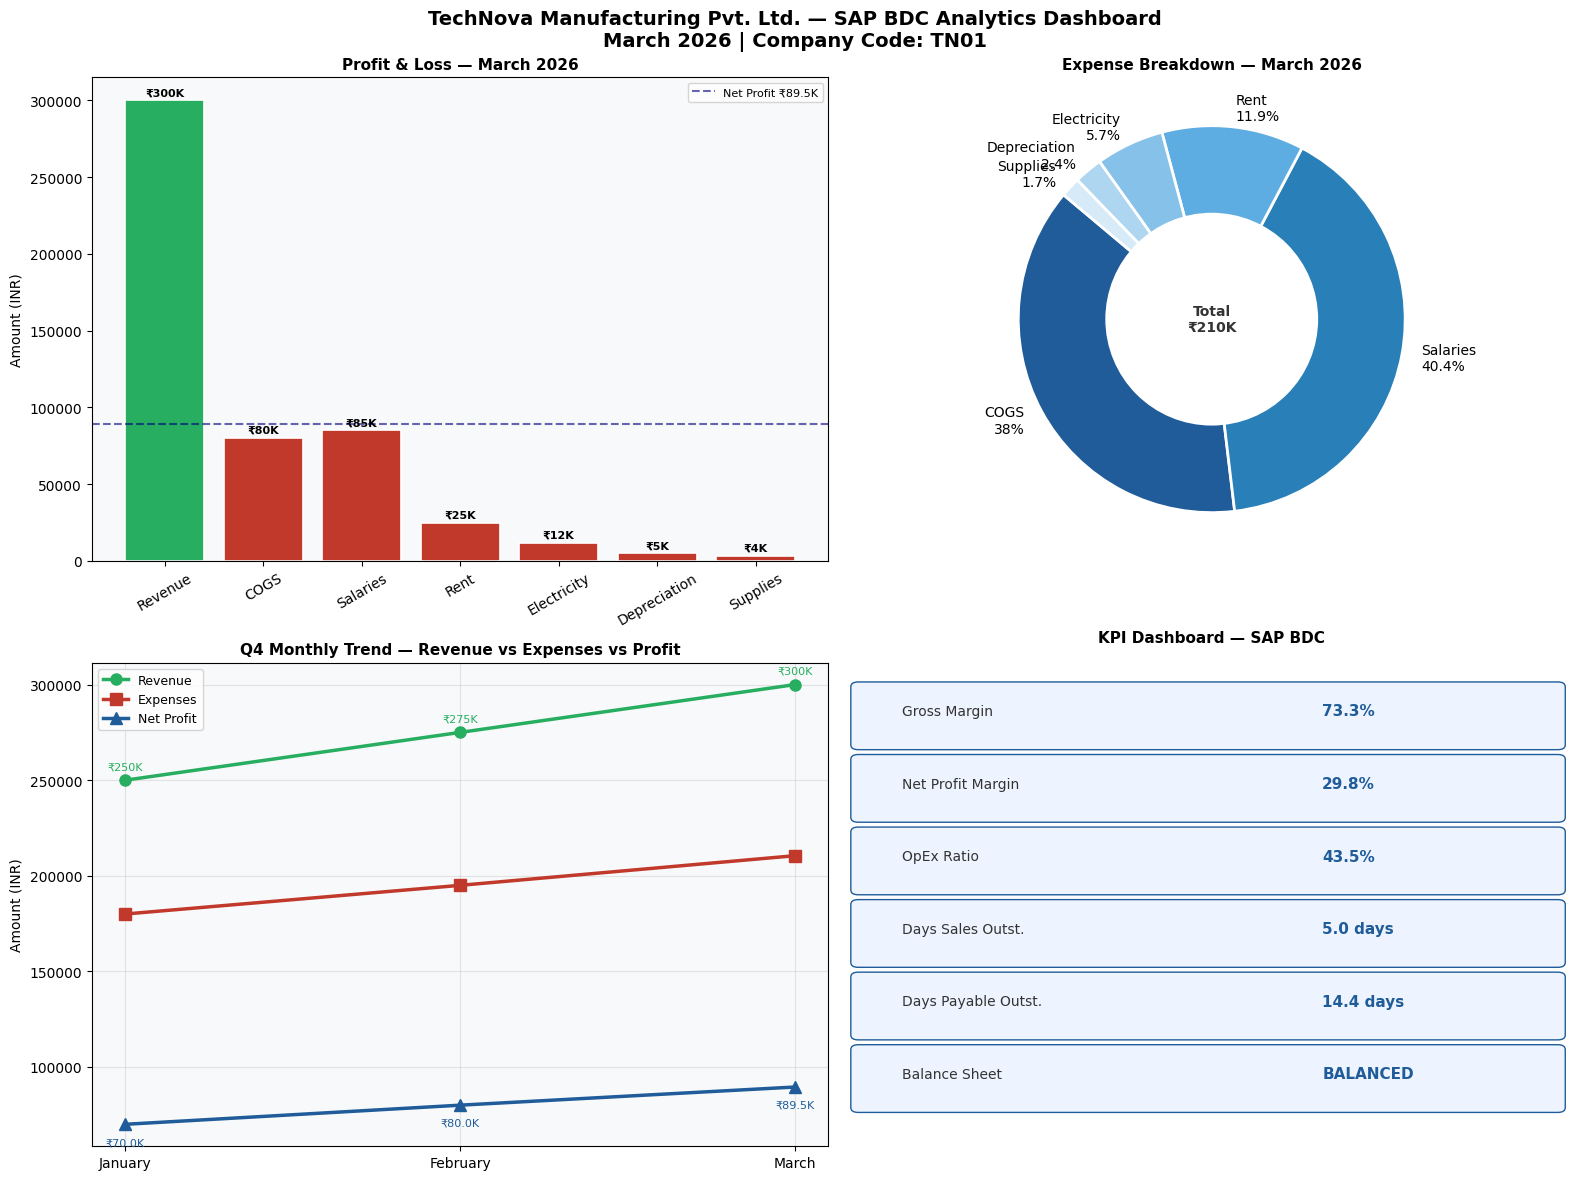

   Dashboard saved as SAP_R2R_Dashboard.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TechNova Manufacturing Pvt. Ltd. — SAP BDC Analytics Dashboard\nMarch 2026 | Company Code: TN01',
             fontsize=14, fontweight='bold', y=0.98)

BLUE   = '#1F5C99'
RED    = '#C0392B'
GREEN  = '#27AE60'
ORANGE = '#E67E22'
COLORS = ['#1F5C99','#2980B9','#5DADE2','#85C1E9','#AED6F1','#D6EAF8']

# ── Chart 1: P&L Bar Chart ───────────────────────────────────────────────
ax1 = axes[0, 0]
categories = ['Revenue', 'COGS', 'Salaries', 'Rent', 'Electricity', 'Depreciation', 'Supplies']
values     = [revenue, cogs, salaries, rent, electricity, depreciation, office_sup]
bar_colors = [GREEN] + [RED]*6
bars = ax1.bar(categories, values, color=bar_colors, edgecolor='white', linewidth=1.2)
ax1.set_title('Profit & Loss — March 2026', fontweight='bold', fontsize=11)
ax1.set_ylabel('Amount (INR)')
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'₹{val/1000:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.axhline(y=net_profit, color='navy', linestyle='--', alpha=0.6, linewidth=1.5, label=f'Net Profit ₹{net_profit/1000:.1f}K')
ax1.legend(fontsize=8)
ax1.set_facecolor('#F8F9FA')

# ── Chart 2: Expense Pie Chart ───────────────────────────────────────────
ax2 = axes[0, 1]
exp_labels = ['COGS\n38%', 'Salaries\n40.4%', 'Rent\n11.9%', 'Electricity\n5.7%', 'Depreciation\n2.4%', 'Supplies\n1.7%']
exp_values = [cogs, salaries, rent, electricity, depreciation, office_sup]
wedges, texts = ax2.pie(exp_values, labels=exp_labels, colors=COLORS,
                         startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Expense Breakdown — March 2026', fontweight='bold', fontsize=11)
centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax2.add_artist(centre_circle)
ax2.text(0, 0, f'Total\n₹{total_expenses/1000:.0f}K', ha='center', va='center',
         fontsize=10, fontweight='bold', color='#333333')

# ── Chart 3: Monthly Revenue Trend ───────────────────────────────────────
ax3 = axes[1, 0]
months   = ['January', 'February', 'March']
rev_data = [250000, 275000, 300000]
exp_data = [180000, 195000, 210500]
pft_data = [70000,  80000,  89500]
x = range(len(months))
ax3.plot(months, rev_data, 'o-', color=GREEN,  linewidth=2.5, markersize=8, label='Revenue')
ax3.plot(months, exp_data, 's-', color=RED,    linewidth=2.5, markersize=8, label='Expenses')
ax3.plot(months, pft_data, '^-', color=BLUE,   linewidth=2.5, markersize=8, label='Net Profit')
for i, (r, e, p) in enumerate(zip(rev_data, exp_data, pft_data)):
    ax3.annotate(f'₹{r/1000:.0f}K', (months[i], r), textcoords='offset points', xytext=(0,8),  ha='center', fontsize=8, color=GREEN)
    ax3.annotate(f'₹{p/1000:.1f}K', (months[i], p), textcoords='offset points', xytext=(0,-15), ha='center', fontsize=8, color=BLUE)
ax3.set_title('Q4 Monthly Trend — Revenue vs Expenses vs Profit', fontweight='bold', fontsize=11)
ax3.set_ylabel('Amount (INR)')
ax3.legend(fontsize=9)
ax3.set_facecolor('#F8F9FA')
ax3.grid(True, alpha=0.3)

# ── Chart 4: KPI Dashboard ───────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')
kpi_display = [
    ('Gross Margin',       f'{gross_margin_pct}%',   ''),
    ('Net Profit Margin',  f'{net_profit_pct}%',     ''),
    ('OpEx Ratio',         f'{opex_ratio}%',         ''),
    ('Days Sales Outst.',  f'{dso} days',            ''),
    ('Days Payable Outst.',f'{dpo} days',            ''),
    ('Balance Sheet',      'BALANCED',               ''),
]
ax4.set_title('KPI Dashboard — SAP BDC', fontweight='bold', fontsize=11, pad=15)
for i, (kpi, val, status) in enumerate(kpi_display):
    y_pos = 0.88 - i * 0.15
    ax4.add_patch(mpatches.FancyBboxPatch((0.02, y_pos-0.05), 0.95, 0.12,
                                           boxstyle='round,pad=0.01',
                                           facecolor='#EEF4FF', edgecolor='#1F5C99', linewidth=1))
    ax4.text(0.08, y_pos+0.02, kpi,    fontsize=10, va='center', color='#333333')
    ax4.text(0.65, y_pos+0.02, val,    fontsize=11, va='center', fontweight='bold', color=BLUE)
    ax4.text(0.90, y_pos+0.02, status, fontsize=12, va='center')

plt.tight_layout()
plt.savefig('SAP_R2R_Dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('   Dashboard saved as SAP_R2R_Dashboard.png')

## 🏁 Step 9 — Final R2R Summary

In [12]:
banner('SECTION 9: FINAL R2R PROCESS SUMMARY  ★')

summary = [
    ['Company Code',          'TN01 — TechNova Manufacturing Pvt. Ltd.'],
    ['Fiscal Period',         'March 2026 (Period 12 / FY 2025-26)'],
    ['GL Accounts Created',   f'{len(GL_ACCOUNTS)} accounts (TNCA Chart of Accounts)'],
    ['Journal Entries Posted',f'{len(posted_documents)} documents (T-Code: FB50)'],
    ['Accruals Posted',       '1 accrual entry (T-Code: FBS1)'],
    ['Depreciation',          f'₹{depreciation:,.0f} posted (Movement Type: AFAB)'],
    ['Period Status',         'LOCKED  (T-Code: OB52)'],
    ['─────────────────',     '──────────────────────────────────────────────'],
    ['Total Revenue',         f'₹{revenue:,.0f}'],
    ['Total Expenses',        f'₹{total_expenses:,.0f}'],
    ['Net Profit',            f'₹{net_profit:,.0f}  ({net_profit_pct}% margin)'],
    ['Total Assets',          f'₹{total_assets:,.0f}'],
    ['Balance Sheet',         f'BALANCED   (Assets = L+E = ₹{total_assets:,.0f})'],
    ['─────────────────',     '──────────────────────────────────────────────'],
    ['Gross Margin',          f'{gross_margin_pct}%  '],
    ['Net Profit Margin',     f'{net_profit_pct}%  '],
    ['Certification Track',   'C_BCBDC — SAP Business Data Cloud Associate'],
    ['Project Topic',         'Record-to-Report (R2R) — Month-End Financial Close'],
]

print(tabulate(summary, headers=['Parameter', 'Value'], tablefmt='fancy_grid'))

print()
print('  ╔═════════════════════════════════════════════════════════════════╗')
print('  ║   SAP R2R RECORD-TO-REPORT CYCLE — COMPLETED SUCCESSFULLY       ║')
print('  ╚═════════════════════════════════════════════════════════════════╝')


══════════════════════════════════════════════════════════════════════
  SECTION 9: FINAL R2R PROCESS SUMMARY  ★
══════════════════════════════════════════════════════════════════════
╒════════════════════════╤════════════════════════════════════════════════════╕
│ Parameter              │ Value                                              │
╞════════════════════════╪════════════════════════════════════════════════════╡
│ Company Code           │ TN01 — TechNova Manufacturing Pvt. Ltd.            │
├────────────────────────┼────────────────────────────────────────────────────┤
│ Fiscal Period          │ March 2026 (Period 12 / FY 2025-26)                │
├────────────────────────┼────────────────────────────────────────────────────┤
│ GL Accounts Created    │ 20 accounts (TNCA Chart of Accounts)               │
├────────────────────────┼────────────────────────────────────────────────────┤
│ Journal Entries Posted │ 13 documents (T-Code: FB50)                        │
├──────────────